# 03 — Modeling (Baselines)

# Predicting Gallstone Disease from Clinical + Bioimpedance + Demographic

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Establish baselines with Logistic Regression, Decision Tree, Random Forest, KNeighbor, SVC, GaussianNB
- Use validation set for model selection
- Record metrics: Accuracy, Precision, Recall, F1, ROC-AUC

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42


# Load processed data
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
feature_names = pd.read_csv("../data/processed/feature_names.csv", header=None)[0].tolist()

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "NaiveBayes": GaussianNB(),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_valid)
    # handle predict_proba if available
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_valid)[:,1]
    else:
        # fallback to decision_function or zeros
        if hasattr(clf, "decision_function"):
            from sklearn.preprocessing import MinMaxScaler
            scores = clf.decision_function(X_valid).reshape(-1,1)
            y_prob = MinMaxScaler().fit_transform(scores).ravel()
        else:
            y_prob = np.zeros_like(y_pred, dtype=float)

    metrics = dict(
        model=name,
        roc_auc=roc_auc_score(y_valid, y_prob) if len(np.unique(y_valid))>1 else np.nan,
        accuracy=accuracy_score(y_valid, y_pred),
        precision=precision_score(y_valid, y_pred),
        recall=recall_score(y_valid, y_pred),
        f1=f1_score(y_valid, y_pred)
    )
    results.append(metrics)

res_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
res_df

,model,roc_auc,accuracy,precision,recall,f1
6,GradientBoosting,0.901042,0.812500,0.826087,0.791667,0.808511
2,RandomForest,0.866319,0.812500,0.826087,0.791667,0.808511
0,LogisticRegression,0.862847,0.750000,0.750000,0.750000,0.750000
4,SVM,0.826389,0.687500,0.714286,0.625000,0.666667
1,DecisionTree,0.770833,0.770833,0.760000,0.791667,0.775510
5,NaiveBayes,0.711806,0.583333,1.000000,0.166667,0.285714
3,KNN,0.703993,0.687500,0.714286,0.625000,0.666667


The table above summarizes the performance of each baseline model on the validation set. The Gradient Boosting model achieved the highest ROC-AUC score (0.90), indicating the strongest ability to distinguish between classes. Random Forest and Logistic Regression follow with ROC-AUC scores around 0.86. Despite having identical accuracy, precision, recall, and F1-scores to Random Forest, Gradient Boosting still performs best overall due to its higher ROC-AUC. K-Nearest Neighbors shows the weakest performance, with a ROC-AUC of 0.70.

## Plot ROC curves for the baselines

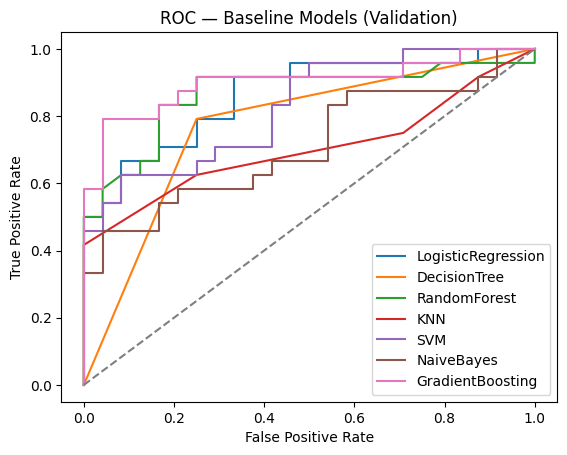

In [31]:
plt.figure()
for name in models.keys():
    # Refit to ensure we have the trained instance here (for clarity)
    match name:
        case "LogisticRegression":
            clf = LogisticRegression(max_iter=1000, random_state=42)
        case "DecisionTree":
            clf = DecisionTreeClassifier(random_state=42)
        case "RandomForest":
            clf = RandomForestClassifier(n_estimators=300, random_state=42)
        case "KNN":
            clf = KNeighborsClassifier(n_neighbors=5)
        case "SVM":
            clf = SVC(probability=True, random_state=42)
        case "NaiveBayes":
            clf = GaussianNB()
        case "GradientBoosting":
            clf = GradientBoostingClassifier(n_estimators=300, random_state=42)
        case _:
            raise ValueError(f"Unknown model name: {name}")

    clf.fit(X_train, y_train)
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_valid)[:,1]
        fpr, tpr, _ = roc_curve(y_valid, y_prob)
        plt.plot(fpr, tpr, label=name)
    elif hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_valid)
        # normalize to [0,1] to plot ROC
        s = (scores - scores.min())/(scores.max()-scores.min()+1e-9)
        fpr, tpr, _ = roc_curve(y_valid, s)
        plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Baseline Models (Validation)")
plt.legend()
plt.show()

The ROC plots above illustrate the performance of each baseline model in distinguishing between the two classes (Gallstone presence vs. absence). The Gradient Boosting model demonstrates the best performance, with its ROC curve closest to the top-left corner, indicating a high true positive rate and low false positive rate. Random Forest and Logistic Regression also show strong performance, with their curves closely following that of Gradient Boosting. In contrast, K-Nearest Neighbors has the least favorable ROC curve, indicating lower discriminative ability compared to the other models.

## Confusion matrix of the best baseline (by ROC-AUC)

Best baseline: GradientBoosting


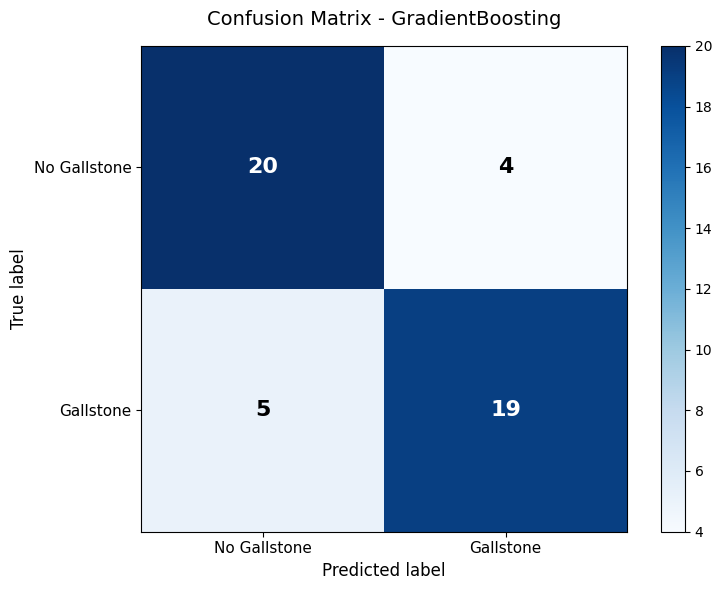

,model,roc_auc,accuracy,precision,recall,f1
6,GradientBoosting,0.901042,0.812500,0.826087,0.791667,0.808511
2,RandomForest,0.866319,0.812500,0.826087,0.791667,0.808511
0,LogisticRegression,0.862847,0.750000,0.750000,0.750000,0.750000
4,SVM,0.826389,0.687500,0.714286,0.625000,0.666667
1,DecisionTree,0.770833,0.770833,0.760000,0.791667,0.775510
5,NaiveBayes,0.711806,0.583333,1.000000,0.166667,0.285714
3,KNN,0.703993,0.687500,0.714286,0.625000,0.666667


In [32]:
best_name = res_df.iloc[0]["model"]
print("Best baseline:", best_name)

# Train & evaluate on validation
if best_name == "LogisticRegression":
    best = LogisticRegression(max_iter=200, random_state=42)
elif best_name == "DecisionTree":
    best = DecisionTreeClassifier(random_state=42)
elif best_name == "RandomForest":
    best = RandomForestClassifier(n_estimators=300, random_state=42)
elif best_name == "KNN":
    best = KNeighborsClassifier(n_neighbors=5)
elif best_name == "NaiveBayes":
    best = GaussianNB()
elif best_name == "GradientBoosting":
    best = GradientBoostingClassifier(n_estimators=300, random_state=42)
else:
    best = SVC(probability=True, random_state=42)

best.fit(X_train, y_train)
y_pred = best.predict(X_valid)
cm = confusion_matrix(y_valid, y_pred)

# Create figure with proper labels
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap=plt.cm.Blues)

# Set ticks and labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Gallstone", "Gallstone"], fontsize=11)
ax.set_yticklabels(["No Gallstone", "Gallstone"], fontsize=11)

# Add labels
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)
ax.set_title(f"Confusion Matrix - {best_name}", fontsize=14, pad=15)

# Add values in cells
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, str(cm[i, j]),
                      ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black",
                      fontsize=16, weight='bold')

# Add colorbar
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

res_df

The confusion matrix above for the Gradient Boosting model shows that it correctly identified 19 true positives (patients with gallstones) and 20 true negatives (patients without gallstones). There were 5 false negatives (patients with gallstones incorrectly classified as not having them) and 4 false positives (patients without gallstones incorrectly classified as having them). This indicates that while the model performs well overall, there is still room for improvement in reducing misclassifications, particularly false negatives which are critical in medical diagnoses.s

## Feature Selection with F-score

In [33]:
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Calculate ANOVA F-scores on training data
F_vals, p_vals = f_classif(X_train, y_train)

# Debug: check lengths to ensure they match
print(f"Number of features in X_train: {X_train.shape[1]}")
print(f"Length of feature_names: {len(feature_names)}")
print(f"Length of F_vals: {len(F_vals)}")

# Clean feature_names - remove header if it exists
clean_feature_names = [name for name in feature_names if name != "0"]
if len(clean_feature_names) != len(F_vals):
    # If still mismatch, regenerate from X_train shape
    print(f"Warning: Feature names length mismatch. Using numeric indices.")
    clean_feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

# Create a table of features ranked by F-score
f_table = pd.DataFrame({
    "feature": clean_feature_names,
    "F_score": F_vals,
    "p_value": p_vals
}).sort_values("F_score", ascending=False)

# ANOVA F-score Analysis Summary
print("="*70)
print("ANALYSIS OF VARIANCE (ANOVA) F-SCORE ANALYSIS")
print("="*70)
print(f"\nTotal features analyzed: {len(F_vals)}")
print(f"F-score range: {F_vals.min():.3f} to {F_vals.max():.3f}")
print(f"Mean F-score: {F_vals.mean():.3f}")
print(f"Median F-score: {np.median(F_vals):.3f}")
print(f"Std deviation: {F_vals.std():.3f}")
print(f"\nFeatures with F >= 1.0: {(F_vals >= 1.0).sum()}")
print(f"Features with F >= 0.70: {(F_vals >= 0.70).sum()}")
print(f"Features with p < 0.05: {(p_vals < 0.05).sum()} (statistically significant)")
print(f"Features with p < 0.01: {(p_vals < 0.01).sum()} (highly significant)")

print("\n" + "="*70)
print("TOP FEATURES BY ANOVA F-SCORE")
print("="*70)
for i, row in f_table.head(38).iterrows():
    sig_marker = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    print(f"{row['feature']:<35} F={row['F_score']:>8.3f}  p={row['p_value']:.4e} {sig_marker}")

print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")

# Remove features with F-score < 0.70
selected_features_df = f_table[f_table['F_score'] >= 0.70]
k_features = selected_features_df.shape[0]
print(f"\nSelecting features with F-score >= 0.70, total selected: {k_features}")

# Create selector
selector = SelectKBest(score_func=f_classif, k=k_features)
selector.fit(X_train, y_train)

# Get selected feature names
selected_indices = selector.get_support(indices=True)
selected_features = [clean_feature_names[i] for i in selected_indices]

# Ordered by F-score
selected_features_sorted = selected_features.copy()
selected_features_sorted.sort(key=lambda x: f_table[f_table['feature'] == x]['F_score'].values[0], reverse=True)

print(f"\nSelected {len(selected_features_sorted)} features:")
for i, feat in enumerate(selected_features_sorted, 1):
    f_score = f_table[f_table['feature'] == feat]['F_score'].values[0]
    print(f"{i:2d}. {feat:<35} (F={f_score:.3f})")

# Transform the data
X_train_selected = selector.transform(X_train)
X_valid_selected = selector.transform(X_valid)

print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

# Compare baseline model performance with feature selection
print("\n" + "="*60)
print("Performance Comparison: All Features vs. Feature Selection")
print("="*60)

for name in ["LogisticRegression", "DecisionTree", "RandomForest", "KNN", "NaiveBayes", "SVM", "GradientBoosting"]:
    if name == "LogisticRegression":
        clf_all = LogisticRegression(max_iter=1000, random_state=42)
        clf_selected = LogisticRegression(max_iter=1000, random_state=42)
    elif name == "DecisionTree":
        clf_all = DecisionTreeClassifier(random_state=42)
        clf_selected = DecisionTreeClassifier(random_state=42)
    elif name == "RandomForest":
        clf_all = RandomForestClassifier(n_estimators=300, random_state=42)
        clf_selected = RandomForestClassifier(n_estimators=300, random_state=42)
    elif name == "KNN":
        clf_all = KNeighborsClassifier(n_neighbors=5)
        clf_selected = KNeighborsClassifier(n_neighbors=5)
    elif name == "NaiveBayes":
        clf_all = GaussianNB()
        clf_selected = GaussianNB()
    else:
        clf_all = SVC(probability=True, random_state=42)
        clf_selected = SVC(probability=True, random_state=42)
    
    # Train with all features
    clf_all.fit(X_train, y_train)
    y_pred_all = clf_all.predict(X_valid)
    roc_auc_all = roc_auc_score(y_valid, y_pred_all)
    
    # Train with selected features
    clf_selected.fit(X_train_selected, y_train)
    y_pred_selected = clf_selected.predict(X_valid_selected)
    roc_auc_selected = roc_auc_score(y_valid, y_pred_selected)
    
    print(f"\n{name}:")
    print(f"  All features ({X_train.shape[1]}):      Accuracy = {roc_auc_all:.4f}")
    print(f"  Selected features ({k_features}):  Accuracy = {roc_auc_selected:.4f}")
    print(f"  Difference:                {roc_auc_selected - roc_auc_all:+.4f}")

Number of features in X_train: 38
Length of feature_names: 39
Length of F_vals: 38
ANALYSIS OF VARIANCE (ANOVA) F-SCORE ANALYSIS

Total features analyzed: 38
F-score range: 0.000 to 30.760
Mean F-score: 4.238
Median F-score: 3.095
Std deviation: 5.799

Features with F >= 1.0: 25
Features with F >= 0.70: 27
Features with p < 0.05: 14 (statistically significant)
Features with p < 0.01: 7 (highly significant)

TOP FEATURES BY ANOVA F-SCORE
Vitamin_D                           F=  30.760  p=8.2998e-08 ***
C-Reactive_Protein_CRP              F=  17.219  p=4.7533e-05 ***
Bone_Mass_BM                        F=  13.360  p=3.2124e-04 ***
Lean_Mass_LM_pct                    F=   8.799  p=3.3445e-03 **
Extracellular_Water_ECW             F=   8.695  p=3.5340e-03 **
Total_Body_Fat_Ratio_TBFR_pct       F=   8.312  p=4.3280e-03 **
Aspartat_Aminotransferaz_AST        F=   7.908  p=5.3631e-03 **
Hyperlipidemia                      F=   6.461  p=1.1713e-02 *
High_Density_Lipoprotein_HDL        F=   5.82